### Explore torch package
Plot differnt activation functions i.e. sigmoid, tahn, 

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import matplotlib_inline


Let's make a single linear layer. $y = Wx + b$ using `torch.nn` package

In [41]:
layer = nn.Linear(1, 20)

In [42]:
print(layer)

Linear(in_features=1, out_features=20, bias=True)


This function takes one-dimensional inputs and spits out 20-dimensional output.

In [43]:
x = torch.rand(10, 1) # 10 randomly sampled one dimensional inputs
print(x)
print(f"Shape of x:{x.shape}")

tensor([[0.7743],
        [0.7539],
        [0.3949],
        [0.5303],
        [0.1901],
        [0.3570],
        [0.4999],
        [0.2053],
        [0.8986],
        [0.8262]])
Shape of x:torch.Size([10, 1])


In [44]:
y = layer(x) # Shape of output should be [10, 20] for each of the inputs there should be 20 outputs
print(y)
print(f'Shape of output is {y.shape}')

tensor([[ 0.3386, -1.2143, -1.2654, -0.7972,  0.3969, -0.3596,  0.5120, -0.3418,
          0.4878,  0.6964,  0.2103, -0.7653,  0.5244, -0.3434,  0.6171,  0.0280,
          0.1943, -1.3349,  1.4422,  0.2835],
        [ 0.3422, -1.1947, -1.2481, -0.7862,  0.3862, -0.3690,  0.4993, -0.3247,
          0.4822,  0.6794,  0.2118, -0.7493,  0.5135, -0.3485,  0.6255,  0.0415,
          0.1791, -1.3232,  1.4283,  0.2730],
        [ 0.4055, -0.8471, -0.9429, -0.5924,  0.1974, -0.5356,  0.2755, -0.0236,
          0.3835,  0.3799,  0.2369, -0.4663,  0.3217, -0.4392,  0.7745,  0.2798,
         -0.0895, -1.1167,  1.1827,  0.0873],
        [ 0.3817, -0.9782, -1.0580, -0.6655,  0.2686, -0.4728,  0.3599, -0.1372,
          0.4207,  0.4929,  0.2274, -0.5731,  0.3941, -0.4050,  0.7183,  0.1899,
          0.0118, -1.1946,  1.2754,  0.1574],
        [ 0.4417, -0.6488, -0.7688, -0.4818,  0.0898, -0.6306,  0.1478,  0.1481,
          0.3272,  0.2090,  0.2512, -0.3049,  0.2123, -0.4909,  0.8594,  0.4158,
      

I think the weights should be of shape (20) and biases should also be of shape (20). Because there are 20 connections between input neuron and output neuron. Each should have one weight and one bias

In [45]:
layer_weight = layer.weight
print(layer.weight)
print(f'The shape of weight parameter is {layer_weight.shape}.')

Parameter containing:
tensor([[-0.1764],
        [-0.9681],
        [-0.8501],
        [-0.5399],
        [ 0.5257],
        [ 0.4640],
        [ 0.6234],
        [-0.8386],
        [ 0.2749],
        [ 0.8342],
        [-0.0699],
        [-0.7882],
        [ 0.5343],
        [ 0.2526],
        [-0.4149],
        [-0.6639],
        [ 0.7481],
        [-0.5751],
        [ 0.6838],
        [ 0.5171]], requires_grad=True)
The shape of weight parameter is torch.Size([20, 1]).


In [46]:
layer_bias = layer.bias
print(layer_bias.type())
print(f'The shape of bias parameter is {layer_bias.shape}')

torch.FloatTensor
The shape of bias parameter is torch.Size([20])


Now let's look at the activation functions.

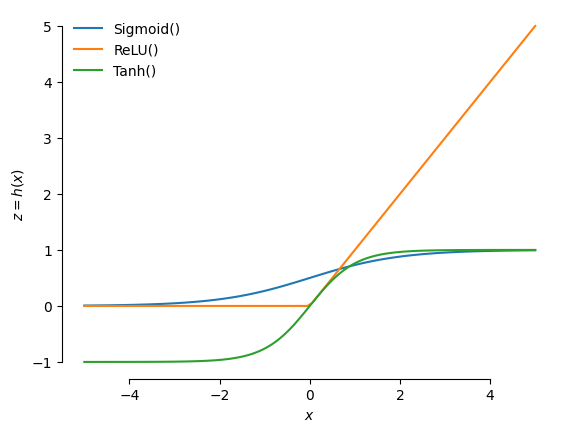

In [53]:
t = torch.linspace(-5, 5, 100)[:, None] # linspace output is one dimensional i.e [100]
# make it two dim [100, 1] so that It can be used as input to NN.

sigmoid_act = nn.Sigmoid()
relu_act = nn.ReLU()
tanh_act = nn.Tanh()
act_func = [sigmoid_act, relu_act, tanh_act]

fig, ax = plt.subplots()
for h in act_func:
    ax.plot(t, h(t), label = str(h))
ax.set_xlabel('$x$')
ax.set_ylabel('$z =h(x)$')
plt.legend(loc='best', frameon = False)
sns.despine(trim = True)

Let's combine linear layer with hte activation function.

In [47]:

h = nn.Sigmoid()
z_func = lambda x: h(layer(x))
print(z_func(x))
print(f"The shape of output after applying non-linearity should be same as before:{z_func(x).shape} ")

tensor([[0.5839, 0.2289, 0.2200, 0.3106, 0.5979, 0.4111, 0.6253, 0.4154, 0.6196,
         0.6674, 0.5524, 0.3175, 0.6282, 0.4150, 0.6496, 0.5070, 0.5484, 0.2084,
         0.8088, 0.5704],
        [0.5847, 0.2324, 0.2230, 0.3130, 0.5954, 0.4088, 0.6223, 0.4195, 0.6183,
         0.6636, 0.5527, 0.3210, 0.6256, 0.4137, 0.6515, 0.5104, 0.5446, 0.2103,
         0.8066, 0.5678],
        [0.6000, 0.3000, 0.2803, 0.3561, 0.5492, 0.3692, 0.5684, 0.4941, 0.5947,
         0.5938, 0.5589, 0.3855, 0.5797, 0.3919, 0.6845, 0.5695, 0.4776, 0.2466,
         0.7654, 0.5218],
        [0.5943, 0.2733, 0.2577, 0.3395, 0.5668, 0.3840, 0.5890, 0.4657, 0.6037,
         0.6208, 0.5566, 0.3605, 0.5973, 0.4001, 0.6722, 0.5473, 0.5029, 0.2324,
         0.7817, 0.5393],
        [0.6087, 0.3433, 0.3167, 0.3818, 0.5224, 0.3474, 0.5369, 0.5370, 0.5811,
         0.5521, 0.5625, 0.4244, 0.5529, 0.3797, 0.7025, 0.6025, 0.4396, 0.2692,
         0.7394, 0.4954],
        [0.6016, 0.3078, 0.2869, 0.3608, 0.5443, 0.3651, 0.5

Now suppose this is a regression task; the output should be a scalar. 
Add a layer that takes 20 inputs and 1 output.

In [32]:
final_layer = nn.Linear(20, 1)
#f = lambda x: final_layer(z_func(x))
# bundle the final layer, the activation function together
f = final_layer(h(y))

print(f)

tensor([[-0.3557],
        [-0.3573],
        [-0.3737],
        [-0.3587],
        [-0.3594],
        [-0.3567],
        [-0.3718],
        [-0.3739],
        [-0.3573],
        [-0.3593]], grad_fn=<AddmmBackward0>)


In [55]:
print(f(x))

tensor([[-0.1237],
        [-0.1653],
        [-0.1579],
        [-0.1629],
        [-0.1443],
        [-0.1205],
        [-0.1628],
        [-0.1634],
        [-0.1459],
        [-0.1529]], grad_fn=<AddmmBackward0>)


* Two things to notice here!
*  `lambda` function is used because it makes callable out of function nesting i.e. in general `f1(f2(x))` throws an error, however, with `f1: lambda \cdot x` and `f2: lambda \cdot x`, `f1(f2)` becomes a functional. --> **It is completely wrong statement.**
*  `lambda` is used so that the two functions linear layer and activation can be bundled into a single reusable **callable**. The benefit of `lambda` is that now the composition can be called on any input.

NN is a bundle of functions. It is important the function bundle is put together into a single reusable callable. So that it can be called on different training and test data. In `torch.nn` we have a class `nn.Sequential` that performs this.

In [34]:
f_seq = nn.Sequential(layer, nn.Sigmoid(), final_layer)
# layer: [10, 1] -> [10, 20] 
# Sigmoid: [10, 20] -> [10, 20]
# final: [10, 20] -> [10, 1]
f_seq

Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=20, out_features=1, bias=True)
)

`matplotlib`  does not like `PyTorch` tensors. It requires to be converted to a numpy array to plot.

In [37]:
f_seq_out = f_seq(x).detach().numpy() # detach actually freezes the parameters to whatever they are
# numpy returns a proper numpy array
print(type(f_seq_out))
print(f_seq_out.shape)

<class 'numpy.ndarray'>
(10, 1)


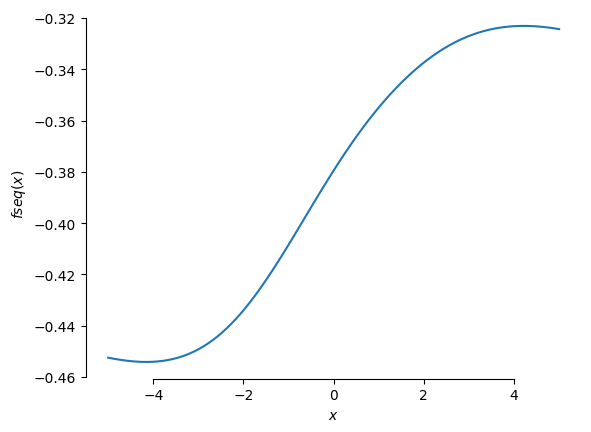

In [54]:
fig, ax = plt.subplots(dpi=100)
ax.plot(t, f_seq(t).detach().numpy())
ax.set_xlabel('$x$')
ax.set_ylabel('$fseq(x)$')
sns.despine(trim = True)

The class `nn.Sequential` is convenient because it allows us to build network quickly. Let's use `nn.Sequential` to build a NN of 3 layers with 20 neurons for regression meaning the output is scaler.

In [55]:
f = nn.Sequential(nn.Linear(1, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 1))


In [56]:
f

Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=20, bias=True)
  (3): ReLU()
  (4): Linear(in_features=20, out_features=20, bias=True)
  (5): ReLU()
  (6): Linear(in_features=20, out_features=1, bias=True)
)

Where are the parameters of the object created in this way.

In [59]:
for theta in f.named_parameters():
    print(theta)

('0.weight', Parameter containing:
tensor([[-0.1771],
        [-0.1666],
        [ 0.9276],
        [ 0.3047],
        [ 0.3986],
        [-0.8710],
        [-0.7272],
        [ 0.3493],
        [ 0.5073],
        [-0.6540],
        [ 0.6144],
        [-0.2134],
        [ 0.4246],
        [ 0.7243],
        [-0.7884],
        [ 0.9228],
        [ 0.4046],
        [ 0.9583],
        [-0.6844],
        [-0.9022]], requires_grad=True))
('0.bias', Parameter containing:
tensor([-0.8677, -0.8986,  0.3007, -0.7761, -0.3990,  0.1402,  0.1092,  0.5650,
         0.4672,  0.3372,  0.5039,  0.0584,  0.8808,  0.3374, -0.5599,  0.1303,
         0.6752,  0.1404, -0.0808, -0.2092], requires_grad=True))
('2.weight', Parameter containing:
tensor([[ 0.1190,  0.0876,  0.0634,  0.0545,  0.1871, -0.0424, -0.0012,  0.0688,
          0.0237,  0.0631, -0.1241,  0.1115,  0.1508, -0.0551,  0.1354, -0.1213,
         -0.2057,  0.0177,  0.0122,  0.0116],
        [ 0.1454, -0.1886, -0.1854,  0.1835, -0.0637,  0.1984

### Making a Loss Function

In [60]:
mse_loss_ours = lambda y, f: torch.mean((y - f) ** 2)

In [64]:
mse_loss_ours

<function __main__.<lambda>(y, f)>

Using built-in PyTorch functionality:

In [65]:
mse_loss = nn.MSELoss()


Let's evaluate the loss for some random data.

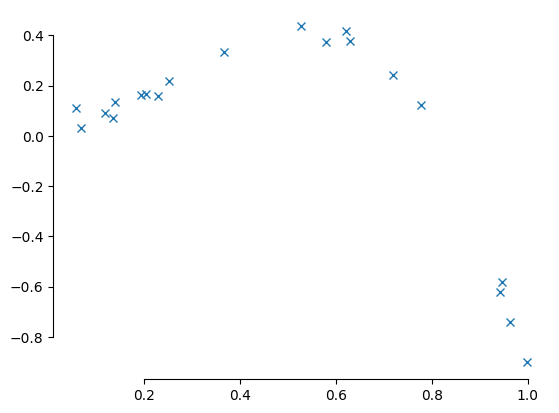

In [66]:
# The number of fake observations
n = 20
# Some fake observed features
x_fake = torch.rand(n, 1)
# Some fake observed targets
y_fake = 4 * x_fake ** 2 - 5 * x_fake ** 3 + 0.1 * torch.rand(n, 1)

# Visualize the data

fig, ax = plt.subplots(dpi=100)
ax.plot(x_fake, y_fake, 'x')
sns.despine(trim=True)

Caculate the mse Loss (for the random parameters that our net started with):

In [67]:
# predict with the net
y_pred = f(x_fake)

# Evaluate the loss

our_loss = mse_loss_ours(y_fake, y_pred)
built_in_loss = mse_loss(y_fake, y_pred)

print(our_loss)
print(built_in_loss)

tensor(0.1608, grad_fn=<MeanBackward0>)
tensor(0.1608, grad_fn=<MseLossBackward0>)


I have a concern regarding grad_fn, it is not same for by-hand implemented mse loss and built-in mse loss. Does it not mean that the backward pass gradient calculation will be different using `autograd`. Let's verify this.

In [74]:
f.zero_grad()
y_pred = f(x_fake)
our_loss = mse_loss_ours(y_fake, y_pred)
our_loss.backward()
grad_ours= [p.grad.clone() for p in f.parameters()]

In [70]:
print(grad_ours)

[tensor([[ 0.0000e+00],
        [ 0.0000e+00],
        [-2.7005e-03],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [-5.4304e-05],
        [ 1.1958e-04],
        [-3.0625e-03],
        [-4.6485e-03],
        [-3.6811e-05],
        [-1.3372e-02],
        [ 7.3072e-05],
        [ 1.6047e-03],
        [-3.6215e-03],
        [ 0.0000e+00],
        [-6.1687e-03],
        [ 4.8792e-03],
        [ 5.2403e-03],
        [ 0.0000e+00],
        [ 0.0000e+00]]), tensor([ 0.0000,  0.0000, -0.0027,  0.0000,  0.0000, -0.0006,  0.0012, -0.0027,
        -0.0043,  0.0003, -0.0127,  0.0010,  0.0014, -0.0033,  0.0000, -0.0061,
         0.0044,  0.0051,  0.0000,  0.0000]), tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,

In [77]:
# zero grads and recompute
f.zero_grad()
y_pred = f(x_fake)
built_in_loss = mse_loss(y_fake, y_pred)
built_in_loss.backward()
grads_builtin = [p.grad.clone() for p in f.parameters()]

# should all be true
all(torch.allclose(a, b) for a, b in zip(grad_ours, grads_builtin))

True

`.clone()` creates an independent copy of the tensor at that moment in time. So it is unaffected by subsequent `zero_grad()` or backward calls.

In [82]:
[p.grad for p in f.parameters()]

[tensor([[ 0.0000e+00],
         [ 0.0000e+00],
         [-2.7005e-03],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [-5.4304e-05],
         [ 1.1958e-04],
         [-3.0625e-03],
         [-4.6485e-03],
         [-3.6811e-05],
         [-1.3372e-02],
         [ 7.3072e-05],
         [ 1.6047e-03],
         [-3.6215e-03],
         [ 0.0000e+00],
         [-6.1687e-03],
         [ 4.8792e-03],
         [ 5.2403e-03],
         [ 0.0000e+00],
         [ 0.0000e+00]]),
 tensor([ 0.0000,  0.0000, -0.0027,  0.0000,  0.0000, -0.0006,  0.0012, -0.0027,
         -0.0043,  0.0003, -0.0127,  0.0010,  0.0014, -0.0033,  0.0000, -0.0061,
          0.0044,  0.0051,  0.0000,  0.0000]),
 tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        

Let's minimize the MSE loss for these fake data and see what fit we will get. Since we only have 20 data points. I will use gradient descent - no random subsampling of the data. 

In [91]:
#1. reinitialize the net:
f = nn.Sequential(nn.Linear(1, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20), 
                  nn.ReLU(),
                  nn.Linear(20, 20), 
                  nn.ReLU(), 
                  nn.Linear(20, 20), 
                  nn.ReLU(),
                  nn.Linear(20, 1))

# 2. Initialize the optimizer - Notice that it all the parameters of the NN needs to registered to the optimizer
optimizer = optim.SGD(f.parameters(), lr= 0.01) # lr is the learning rate i.e. weight = weight - lr*gradient

# 3. define MSE LOSS
x_fake = torch.rand(20, 1)
y_fake = 4 * x_fake ** 2 - 5 * x_fake ** 3 + 0.1 * torch.rand(20, 1)

mse_loss = nn.MSELoss()

training_loss = []

for i in range(10000):

    # 3.0 initialize the autograd graph
    optimizer.zero_grad()
    # 3.1 do the predictions
    y_predict = f(x_fake)

    # 3.2 Evaluate the loss
    loss = mse_loss(y_fake, y_predict)
    # Evaluate the derivatives of the loss wrt 
    # all parameters - It knows how to do it because 
    # of PyTorch magic
    loss.backward()

    # make a step meaning update the weights    
    optimizer.step()

    # Save the training loss of later visualizations
    training_loss.append(loss.item())

    # Print the loss every 1000  iterations:
    if i % 1000 == 0:
        print('it={0:d}: loss = {1:1.3f}'.format(i, loss.item()))

it=0: loss = 0.070
it=1000: loss = 0.036
it=2000: loss = 0.035
it=3000: loss = 0.035
it=4000: loss = 0.034
it=5000: loss = 0.033
it=6000: loss = 0.030
it=7000: loss = 0.024
it=8000: loss = 0.012
it=9000: loss = 0.004


Let's plot the predictions of this model on the fake data:

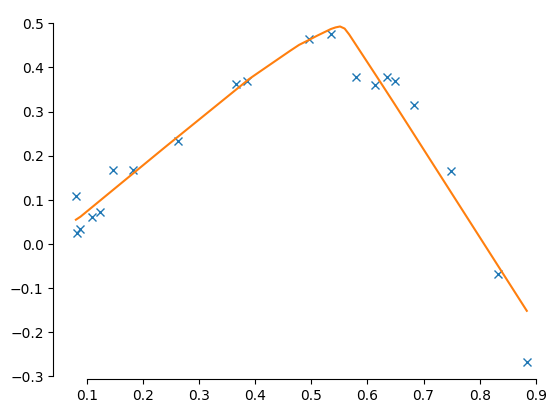

In [92]:
fig, ax = plt.subplots(dpi=100)
ax.plot(x_fake, y_fake, 'x')
xx = torch.linspace(x_fake.min(), x_fake.max(), 100)[:,None]
yy = f(xx).detach().numpy()
ax.plot(xx, yy)
sns.despine(trim = True)

This may or may not work, depending on what random seed you start with. It may stack at some local minimum if you run it a few times. This algorithm is excellent if we do stachastic optimization i.e. subsampling the data.
Here is how the loss changes with each iteration.

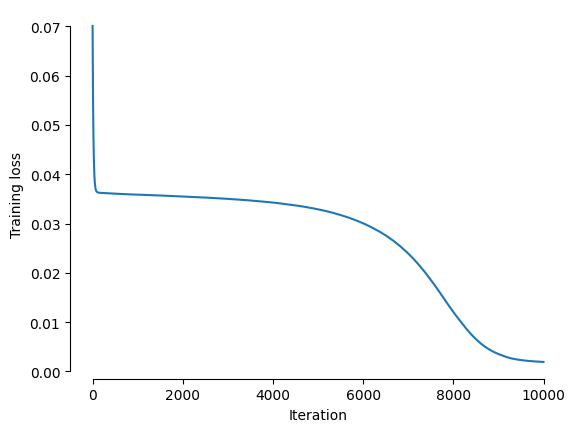

In [93]:
fig, ax = plt.subplots(dpi = 100)
ax.plot(training_loss)
ax.set_xlabel('Iteration')
ax.set_ylabel('Training loss')
sns.despine(trim = True)

The optimizer used above is actually gradient descent. Because there was no random subsampling of data into batches.
The plateauing at the beginning of the optimization shows the algorithm got stuck for large period of time in some local minima.

Let's redo this thing with stochastic optimization. For stochastic optimization, we need to subsample the data during each iteration. We can either do this manually or use the `Pytorch` functionality. First, let's do it manually.

In [113]:
import numpy as np
# pick a subasampling size
m = 10

# Reinitialize the network
f = nn.Sequential(nn.Linear(1, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 1))

# Reinitialize the optimizer
optimizer = optim.SGD(f.parameters(), lr= 0.01)


# Keep track of the training loss
training_loss_sgd = []

for i in range(20000):

    # Zero out the gradient buffers
    optimizer.zero_grad()

    # Sample m observation indices at random
    idx = np.random.randint(0, n, m)
    # Here is a subsmaple of data
    x_fake_bat = x_fake[idx]
    y_fake_bat =y_fake[idx]

    # predictions from the network
    y_pred = f(x_fake_bat)
    # Evaluate the loss - That's what you are evaluating
    loss = mse_loss(y_fake_bat, y_pred)
    # Evaluate the derivatives of the loss wrt 
    # all parameters - It knows how to do it because of 
    # PyTorch magick
    loss.backward()

    # Make a step - update the weights
    optimizer.step()

    # Keep track of the training loss
    training_loss_sgd.append(loss.item())

    # Print the loss every 1000 iterations
    if i % 1000 == 0:
        print('it = {0:d}: loss = {1:1.2e}'.format(i, loss.item()))

    

it = 0: loss = 8.73e-02
it = 1000: loss = 4.26e-02
it = 2000: loss = 4.98e-02
it = 3000: loss = 2.11e-02
it = 4000: loss = 4.23e-02
it = 5000: loss = 3.77e-02
it = 6000: loss = 2.75e-02
it = 7000: loss = 3.48e-02
it = 8000: loss = 8.37e-03
it = 9000: loss = 9.80e-04
it = 10000: loss = 2.96e-03
it = 11000: loss = 1.14e-03
it = 12000: loss = 4.60e-04
it = 13000: loss = 7.10e-04
it = 14000: loss = 7.09e-04
it = 15000: loss = 1.19e-03
it = 16000: loss = 1.39e-03
it = 17000: loss = 1.39e-03
it = 18000: loss = 8.65e-04
it = 19000: loss = 7.20e-04


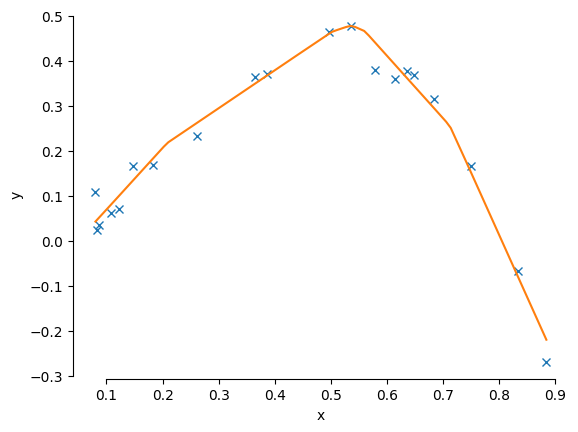

In [114]:
fig, ax = plt.subplots(dpi=100)
ax.plot(x_fake, y_fake, 'x')
xx = torch.linspace(x_fake.min(), x_fake.max(), 100 )[:, None]
yy = f(xx).detach().numpy()
ax.plot(xx, yy)
ax.set_xlabel('x')
ax.set_ylabel('y')
sns.despine(trim=True)

Plot the loss function

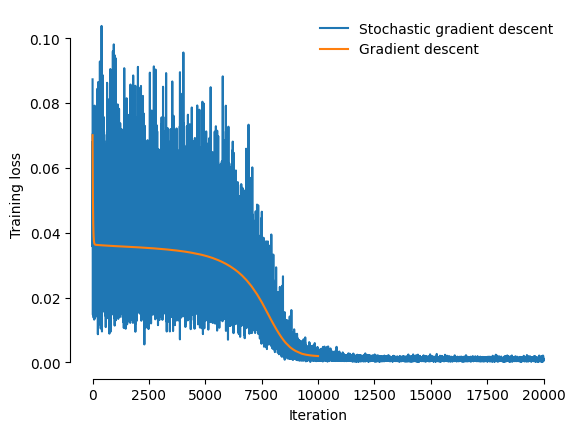

In [115]:
fig, ax = plt.subplots(dpi=100)
ax.plot(training_loss_sgd, label = 'Stochastic gradient descent')
ax.plot(training_loss, label='Gradient descent')
ax.set_xlabel('Iteration')
ax.set_ylabel('Training loss')
plt.legend(loc='best', frameon=False)
sns.despine(trim = True)


So, I have to tune a bit to get the SGD work probably because of small data size and even smaller batch size. The wiggly nature of stochastic gradient descent allows it to escape bad local minima.

# Example - Motorcycle Data

Let's now use motorcycle data to do regression with DNNs. This will help us demonstrate some best practices specifically:
* Standardizing the data
* Splitting the training and test subsets

The data is already their in the repository

In [5]:
# Load the data
data = np.loadtxt('..\\..\\lecturebook\\data\\motor.dat')

In [6]:
x = data[:,0][:,None]
y = data[:,1][:,None]

In [7]:
# split into training and test datasets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

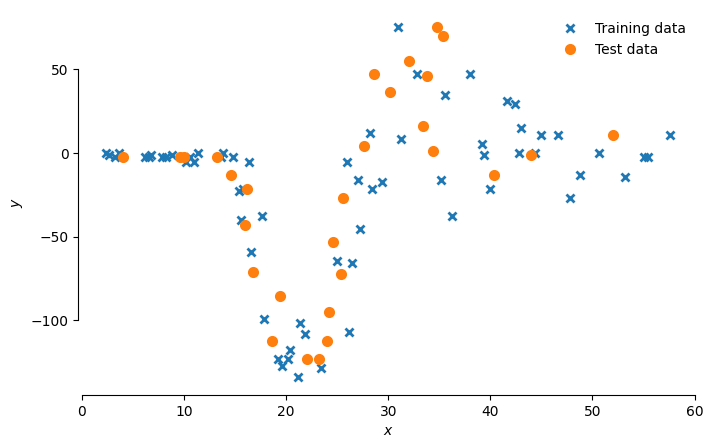

In [8]:
# Visualize them
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_train, y_train, 'x', markeredgewidth=2, label='Training data')
ax.plot(x_test, y_test, 'o', markeredgewidth=2, label='Test data')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.legend(loc='best', frameon=False)
sns.despine(trim=True)

In [9]:
# Turn the data into torch tensors:
x_train = torch.tensor(x_train, dtype=torch.float)
y_train =torch.tensor(y_train, dtype= torch.float)
x_test = torch.tensor(x_test, dtype= torch.float)
y_test = torch.tensor(y_test, dtype=torch.float)

Note that `dtype= torch.float` specification is absolutely needed here. It is required for code to work. The problem is that the `x_train`, ect., are all numpy arrays and that numpy arrays have 64-bit floating point numbers by default. PyTorch is using 32-bit floating point numbers by default. So, we need to make the two compatible at some point of time.  

Now, we are ready to train the network. Let's give it a shot. We will use the same architecture as before. The only difference is that I will print validation loss instead of the training loss.

In [11]:
# The number of training samples
n = x_train.shape[0]

# Pick a subsampling batch size
m = 5

# Reinitialize the net
f = nn.Sequential(nn.Linear(1, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 1))

# define Loss
mse_loss = nn.MSELoss()

# Reinitialize the optimizer
optimizer = optim.SGD(f.parameters(), lr= 0.001)

# Keep track of training loss and test loss
training_loss = []
test_loss = []

# Iterate the optimizer. Let's just do it for 10 iterations.
for i in range(20000):

    # Zero out the gradient buffers
    optimizer.zero_grad()

    # Sample m observations iterations at random
    idx = np.random.randint(0, n, m)
    # Here is the subsample of the data
    x_batch = x_train[idx]
    y_batch = y_train[idx]

    # Make predictions
    y_pred = f(x_batch)

    # Evaluate the loss - That's what you are minimizing
    loss = mse_loss(y_batch, y_pred)
    training_loss.append(loss.item())

    # Evaluate the derivative of the loss with respect to
    # all parameters - It knows how to do it because of 
    # PyTorch magick
    loss.backward()
    # And now you are ready to make a step
    optimizer.step()
    #Evaluate the test loss
    y_pred_test = f(x_test)
    ts_loss = mse_loss(y_test, y_pred_test)
    test_loss.append(ts_loss.item())
    # Print the loss every one humdred iterations:
    if i % 1000 == 0:
     print('it = {0:d}: loss = {1:1.2e}'.format(i, ts_loss.item()))
     




it = 0: loss = 3.71e+03
it = 1000: loss = 3.28e+03
it = 2000: loss = 3.27e+03
it = 3000: loss = 3.27e+03
it = 4000: loss = 3.29e+03
it = 5000: loss = 3.41e+03
it = 6000: loss = 3.27e+03
it = 7000: loss = 3.35e+03
it = 8000: loss = 3.27e+03
it = 9000: loss = 3.27e+03
it = 10000: loss = 3.27e+03
it = 11000: loss = 3.28e+03
it = 12000: loss = 3.28e+03
it = 13000: loss = 3.27e+03
it = 14000: loss = 3.28e+03
it = 15000: loss = 3.29e+03
it = 16000: loss = 3.27e+03
it = 17000: loss = 3.27e+03
it = 18000: loss = 3.27e+03
it = 19000: loss = 3.27e+03


The above code may not work at all, giving you nan's. Or it may work and get you nowhere. The problem here is the scale of both the inputs and the outputs and the assumptions that have been made about them when we initalize the weights of the net and when we pick the learning rate of the optimization algorithm. -> I tried changing the learning rate and it is possible to get non nan values but I see it is not converging.  

The easiest way to overcome this problem is to *standardize the data*. This is achieved by subtracting the empirical mean and dividing the inputs and the outputs by the empirical standard deviation. By standardizing the data, we are making the default parameters (for weight initialization and stochastic gradient descent) valid again. Standardization is such a common process that it is already implemented in [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

In [12]:
from sklearn.preprocessing import StandardScaler
feature_scaler = StandardScaler().fit(x)
target_scaler = StandardScaler().fit(y)

The `feature_scaler.transform()` is a function: $$x \rightarrow \frac{x - \mu}{\sigma},$$ where $\mu$ and $\sigma$ are features' empirical mean and standard deviation. Here they are:

In [ ]:
# The feature mean:
feature_scaler.mean_

array([25.9])

In [15]:
# The target mean:
target_scaler.mean_

array([-21.78404255])

In [ ]:
# The feature standard deviation:
feature_scaler.scale_

array([13.88042399])

In [16]:
# The target standard deviation:
target_scaler.scale_

array([50.31569761])

And here is how the scalers work:

In [17]:
x_scaled = feature_scaler.transform(x)
y_scaled = feature_scaler.transform(y)

Plot the data to see that they are scaled now

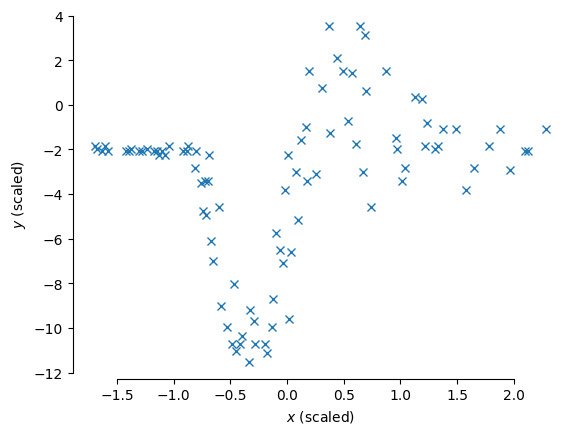

In [18]:
fig, ax = plt.subplots(dpi=100)
ax.plot(x_scaled, y_scaled, 'x')
ax.set_xlabel('$x$ (scaled)')
ax.set_ylabel('$y$ (scaled)')
sns.despine(trim=True)

We will train the the net using `x_scaled` and `y_scaled`. We can always go back to the original scales at the end. Let's see if it works.

In [ ]:
# Splitting the data into train and test
xs_train, xs_test, ys_train, ys_test = train_test_split(x_scaled, y_scaled, test_size = 0.3)

# Turn the data into torch tensors
xs_train = torch.tensor(xs_train, dtype=torch.float)
ys_train = torch.tensor(ys_train, dtype=torch.float)
xs_test = torch.tensor(xs_train, dtype=torch.float)
ys_test = torch.tensor(ys_test, dtype= torch.float)

# The number of training samples
n = xs_train.shape[0]
nt = xs_test.shape[0]
# Subsample batch size
m = 5

# Reinitialize the net
f = nn.Sequential(nn.Linear(1, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 20),
                  nn.ReLU(),
                  nn.Linear(20, 1))


# Reinitialize the optimizer
optimizer = optim.SGD(f.parameters(), lr=0.01)

# Placeholder for train and test loss
training_loss = []
test_loss = []

for i in range(10000):

    # Zero out the gradient buffers
    optimizer.zero_grad()

    # Choose random batch
    idx = np.random.randint(0, n, m)
    idx_t = np.random.randint(0, nt, m)
    # batch data
    xs_train_batch = xs_train[idx]
    ys_train_batch = ys_train[idx]

    xs_test_batch = xs_test[idx_t]
    ys_test_batch = ys_test[idx_t]

    # evaluate loss
    predict = f(xs_train_batch)
    loss = mse_loss(ys_train_batch, predict)

    # compute test loss
    test_predict_batch = f(xs_test_batch)
    test_mse = mse_loss(ys_test_batch, test_predict_batch)

    # calculate grdient: The PyTorch magic
    loss.backward()

    # Update the weights
    optimizer.step()


    # store train and test loss
    training_loss.append(loss.item())
    test_loss.append(test_mse)

    if i % 1000 == 0:
        print('it: {0:1f} train loss:{0:3d} test_loss:{0:3d}'.format(i, loss.item(), test_mse.item()))






C:\Users\GautamVishwa\AppData\Local\Temp\ipykernel_21028\953904387.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xs_test = torch.tensor(xs_train, dtype=torch.float)


IndexError: index 57 is out of bounds for dimension 0 with size 29

In [28]:
ys_train.size()

torch.Size([29, 1])